In [4]:
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [5]:

# Load only specific columns
particles = load_dataset(
    "CERN/ColliderML-Release-1",
    "ttbar_pu0_calo_hits",
    split="train",
    
    streaming=True, 
)




Resolving data files:   0%|          | 0/100 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1000 [00:00<?, ?it/s]

In [44]:
NUM_EVENTS = 100

keys = ["total_energy", "x", "y", "z", "detector"]

data_dir = {key:[] for key in keys}
energies, x, y, z, detector = {}, {}, {}, {}, {}


for i, event in enumerate(tqdm(particles, total=NUM_EVENTS)):
    if i >= NUM_EVENTS:
        break

    for key in data_dir.keys():
        data_dir[key].append(event[key])

   
for key in data_dir.keys():
    data_dir[key] = np.concatenate(data_dir[key])


100%|██████████| 100/100 [00:42<00:00,  2.37it/s]


In [45]:
data_dir["r"] = np.sqrt(data_dir["x"]**2 + data_dir["y"]**2)

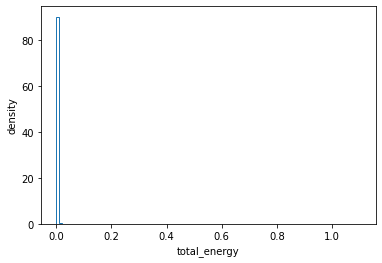

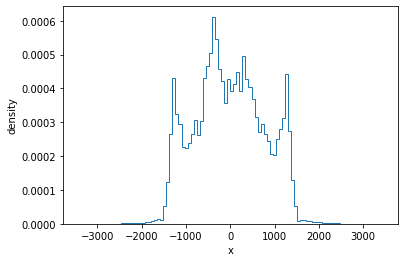

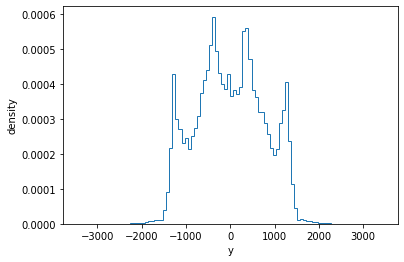

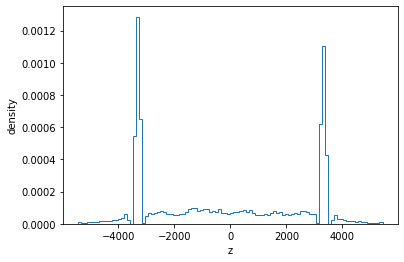

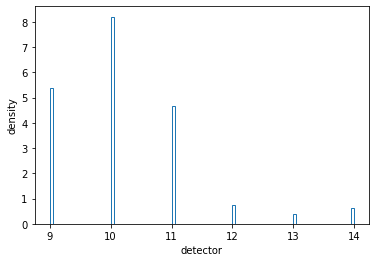

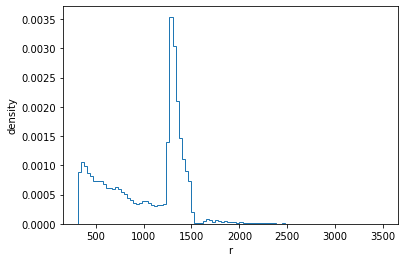

In [46]:
for key in data_dir.keys():
    plt.figure()
    plt.hist(data_dir[key], bins = 100, histtype = "step", density = True)
    plt.xlabel(key)
    plt.ylabel("density")
    plt.show()

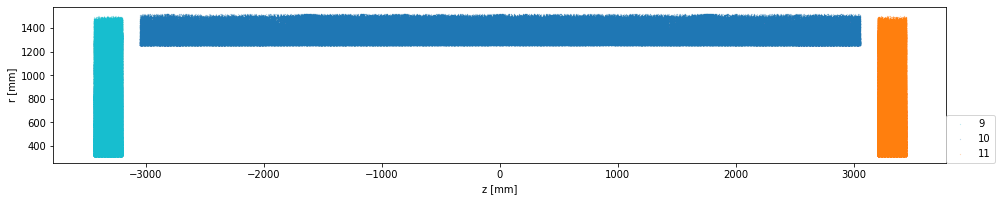

In [47]:
ECAL_layers = [9, 10, 11]

plt.figure(figsize = (16, 6))
for detector_idx in ECAL_layers:
    detector_mask = data_dir["detector"] == detector_idx
    plt.scatter(
        data_dir["z"][detector_mask], 
        data_dir["r"][detector_mask], 
        color = f"C{detector_idx}", 
        s = 0.01,
        label = detector_idx
        )
plt.legend(loc = (1, 0))
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel("z [mm]")
plt.ylabel("r [mm]")
plt.show()



12
118909
36
118909
2610

14
103899
36
103899
2708



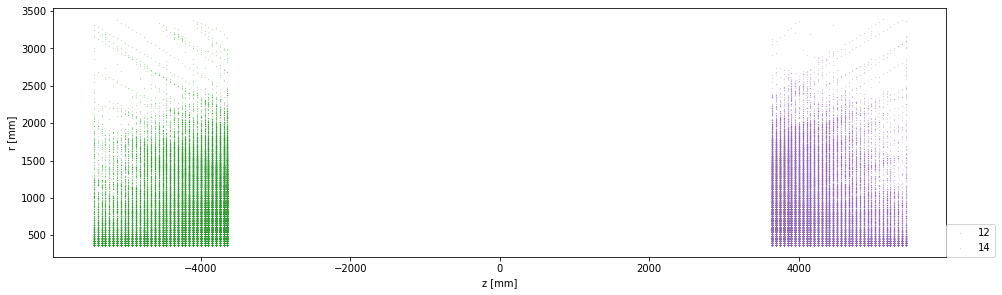

12
len z 118909
unique z 36
len r 118909
unique r 2610

14
len z 103899
unique z 36
len r 103899
unique r 2708



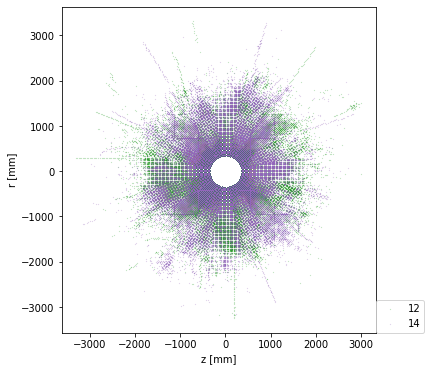

In [49]:
# endcaps
HCAL_layers = [12, 14]

plt.figure(figsize = (16, 6))
for detector_idx in HCAL_layers:
    detector_mask = data_dir["detector"] == detector_idx
    plt.scatter(
        data_dir["z"][detector_mask], 
        data_dir["r"][detector_mask], 
        color = f"C{detector_idx}", 
        s = 0.01,
        label = detector_idx
        )
    print(detector_idx)
    print(len(data_dir["z"][detector_mask]))
    print(len(set(data_dir["z"][detector_mask])))
    print(len(data_dir["r"][detector_mask]))
    print(len(set(data_dir["r"][detector_mask])))
    print()
plt.legend(loc = (1, 0))
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel("z [mm]")
plt.ylabel("r [mm]")
plt.show()


plt.figure(figsize = (16, 6))
for detector_idx in HCAL_layers:
    detector_mask = data_dir["detector"] == detector_idx
    plt.scatter(
        data_dir["x"][detector_mask], 
        data_dir["y"][detector_mask], 
        color = f"C{detector_idx}", 
        s = 0.01,
        label = detector_idx
        )
    print(detector_idx)
    print("len z", len(data_dir["z"][detector_mask]))
    print("unique z", len(set(data_dir["z"][detector_mask])))
    print("len r", len(data_dir["r"][detector_mask]))
    print("unique r", len(set(data_dir["r"][detector_mask])))
    print()
plt.legend(loc = (1, 0))
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel("z [mm]")
plt.ylabel("r [mm]")
plt.show()



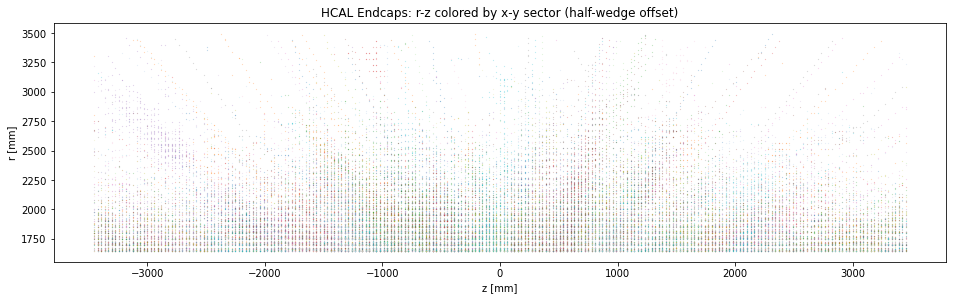

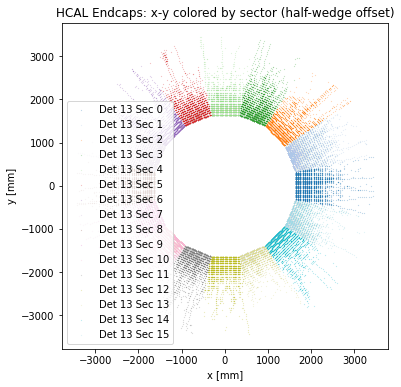

In [167]:
import numpy as np
import matplotlib.pyplot as plt

HCAL_layers = [13]
n_sectors = 16  # number of radial sectors
half_wedge = np.pi / n_sectors  # half-sector offset
sector_colors = plt.cm.tab20(np.linspace(0, 1, n_sectors))  # 16 distinct colors

# Compute sector index with optional offset
def compute_sector(x, y, n_sectors, offset=0.0):
    angles = np.arctan2(y, x)  # range [-pi, pi]
    angles[angles < 0] += 2 * np.pi  # shift to [0, 2pi]
    angles = (angles + offset) % (2 * np.pi)  # apply offset
    sector_idx = (angles / (2 * np.pi) * n_sectors).astype(int)
    return sector_idx

# --- Plot r-z view with half-sector offset ---
plt.figure(figsize=(16, 6))
for detector_idx in HCAL_layers:
    detector_mask = data_dir["detector"] == detector_idx
    x = data_dir["x"][detector_mask]
    y = data_dir["y"][detector_mask]
    z = data_dir["z"][detector_mask]
    r = data_dir["r"][detector_mask]

    sectors = compute_sector(x, y, n_sectors, offset=half_wedge)
    
    for sec in range(n_sectors):
        sec_mask = sectors == sec
        plt.scatter(
            z[sec_mask],
            r[sec_mask],
            color=sector_colors[sec],
            s=0.01,
            label=f"Det {detector_idx} Sec {sec}" if sec == 0 else None
        )

plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel("z [mm]")
plt.ylabel("r [mm]")
plt.title("HCAL Endcaps: r-z colored by x-y sector (half-wedge offset)")
plt.show()


# --- Plot x-y view with half-sector offset ---
plt.figure(figsize=(16, 6))
for detector_idx in HCAL_layers:
    detector_mask = data_dir["detector"] == detector_idx
    x = data_dir["x"][detector_mask]
    y = data_dir["y"][detector_mask]
    
    sectors = compute_sector(x, y, n_sectors, offset=half_wedge)
    
    for sec in range(n_sectors):
        sec_mask = sectors == sec
        plt.scatter(
            x[sec_mask],
            y[sec_mask],
            color=sector_colors[sec],
            s=0.01,
            label=f"Det {detector_idx} Sec {sec}"
        )

plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel("x [mm]")
plt.ylabel("y [mm]")
plt.legend()
plt.title("HCAL Endcaps: x-y colored by sector (half-wedge offset)")
plt.show()

In [ ]:
import numpy as np


def assign_hits_to_cells(x, y, z, detector_index, n_sectors=16, cell_size=30.0, half_wedge=np.pi/16):
    """
    Assign hits to HCAL cells in endcap.
    Sector 0 is fixed; all other sectors rotated to align with sector 0.
    """

    #TODO: Z = ABS Z
    # TODO failsafe if dcant be indexed

    # HCAL
    if detector_index in [12, 13, 14]:
        cell_size = 30.0 # mm
        layer_width = 51.0 # mm
        y_start, y_stop = -660.0, 660.0
    # ECAL
    elif detector_index in [9, 10, 11]:
        cell_size = 5.1 # mm
        layer_width = 5.05 # mm
        y_start, y_stop = -295.8, 295.8

    # HCAL endcaps
    if detector_index in [12, 14]:
        x_start, x_stop = 362.5, 3362.5
        z_start, z_stop = 3647.5, 5483.5 # 36 layers 
    
    # HCAL barrel
    elif detector_index in [13]:
        x_start, x_stop = 1647.5, 3483.5 # 36 layers
        z_start, z_stop = -3450.0, 3450.0
        
    # ECAL endcaps
    elif detector_index in [9, 11]:
        x_start, x_stop = 316.8, 1469.4
        z_start, z_stop = 3202.4, 3439.75 # 48 layers
    
    # ECAL barrel
    elif detector_index in [10]:
        x_start, x_stop = 1252.4, 1494.8 # 48 layers
        z_start, z_stop = -3049.8, 3049.8


    if detector_index in [9, 11, 12, 14]:
        # layers in z
        x_edges = np.arange(np.round(x_start - cell_size/2, 1), np.round(x_stop + cell_size/2, 1) + 1, cell_size)
        y_edges = np.arange(np.round(y_start - cell_size/2, 1), np.round(y_stop + cell_size/2, 1) + 1, cell_size)
        z_edges = np.arange(np.round(z_start - layer_width/2, 1), np.round(z_stop + layer_width/2, 1) + 1, layer_width)

    elif detector_index in [10, 13]:
        # layers in x
        x_edges = np.arange(np.round(x_start - layer_width/2, 1), np.round(x_stop + layer_width/2, 1) + 1, layer_width)
        y_edges = np.arange(np.round(y_start - cell_size/2, 1), np.round(y_stop + cell_size/2, 1) + 1, cell_size)
        z_edges = np.arange(np.round(z_start - cell_size/2, 1), np.round(z_stop + cell_size/2, 1) + 1, cell_size)

    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)

    

    # --- Step 1: compute wedge ---
    angles = np.arctan2(y, x)
    angles[angles < 0] += 2*np.pi
    angles = (angles + half_wedge) % (2*np.pi)
    sector_idx = (angles / (2*np.pi) * n_sectors).astype(int)

    # --- Step 2: compute rotation angles to align with sector 0 ---
    delta_theta = 2*np.pi / n_sectors
    theta_center = (sector_idx + 0.5) * delta_theta
    theta_center_0 = (0 + 0.5) * delta_theta  # sector 0 center angle

    theta_rot = - (theta_center - theta_center_0)  # rotate other sectors to align with sector 0

    # --- Step 3: rotate hits into sector 0-aligned frame ---
    x_local = x * np.cos(theta_rot) - y * np.sin(theta_rot)
    y_local = x * np.sin(theta_rot) + y * np.cos(theta_rot)

    """
    print("x")
    tmp = np.unique(np.round(x_local, 2))
    print(tmp)
    print(tmp[1:] - tmp[:-1])
    print(np.min(tmp), np.max(tmp))

    print("y")
    tmp = np.unique(np.round(y_local, 2))
    print(tmp)
    print(tmp[1:] - tmp[:-1])
    print(np.min(tmp), np.max(tmp))

    print("z")
    tmp = np.unique(np.round(z, 2))
    print(tmp)
    print(tmp[1:] - tmp[:-1])
    print(np.min(tmp), np.max(tmp))
    """

    

    # --- Step 5: assign hits to cell indices ---
    x_cell_idx = np.digitize(x_local, x_edges) - 1  # subtract 1 to make 0-based
    y_cell_idx = np.digitize(y_local, y_edges) - 1
    z_cell_idx = np.digitize(z, z_edges) - 1

    return sector_idx, x_cell_idx, y_cell_idx, z_cell_idx, x_local, y_local

  

# Example: assign cells for detector hits
x = data_dir["x"][data_dir["detector"] == 10]
y = data_dir["y"][data_dir["detector"] == 10]
z = data_dir["z"][data_dir["detector"] == 10]

sectors, x_cell_idx, y_cell_idx, z_cell_idx,  x_local, y_local  = assign_hits_to_cells(x, y, z, 10)

x
[1252.4  1252.7  1257.45 1262.5  1267.55 1272.6  1273.31 1277.65 1277.98
 1282.7  1287.75 1292.8  1297.85 1298.59 1302.9  1303.26 1307.95 1313.
 1318.05 1323.1  1323.87 1328.15 1328.54 1333.2  1338.25 1343.3  1348.35
 1353.4  1353.82 1358.45 1358.48 1363.5  1368.55 1373.6  1378.65 1379.1
 1383.7  1383.76 1388.75 1393.8  1398.85 1403.9  1404.38 1408.95 1409.04
 1414.   1419.05 1424.1  1429.15 1429.66 1434.2  1434.32 1439.25 1444.3
 1449.35 1454.4  1454.94 1459.45 1459.6  1464.5  1469.55 1474.6  1479.65
 1480.22 1484.7  1484.88 1489.75]
[0.3  4.75 5.05 5.05 5.05 0.71 4.34 0.33 4.72 5.05 5.05 5.05 0.74 4.31
 0.36 4.69 5.05 5.05 5.05 0.77 4.28 0.39 4.66 5.05 5.05 5.05 5.05 0.42
 4.63 0.03 5.02 5.05 5.05 5.05 0.45 4.6  0.06 4.99 5.05 5.05 5.05 0.48
 4.57 0.09 4.96 5.05 5.05 5.05 0.51 4.54 0.12 4.93 5.05 5.05 5.05 0.54
 4.51 0.15 4.9  5.05 5.05 5.05 0.57 4.48 0.18 4.87]
1252.4 1489.75
y
[-295.8  -294.89 -292.95 -290.7  -289.94 -288.   -285.6  -284.98 -283.05
 -280.5  -280.03 -278.1  -275.4

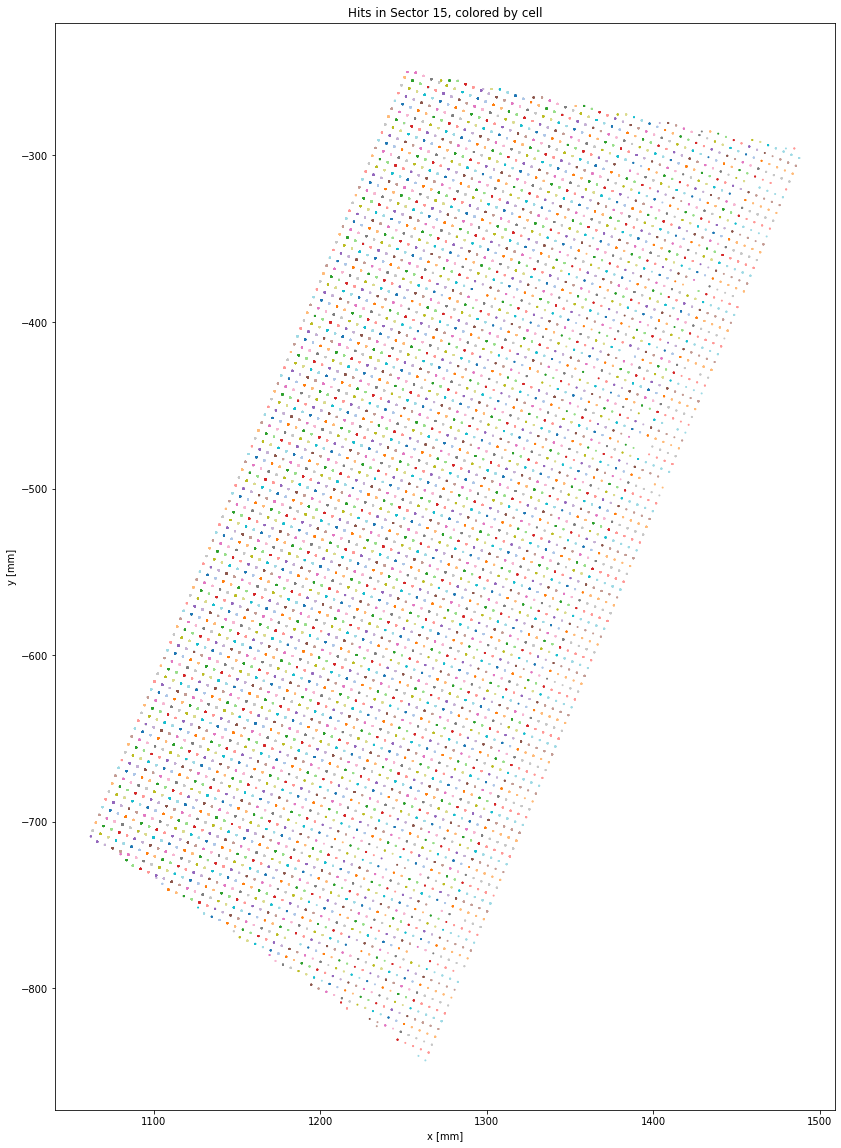

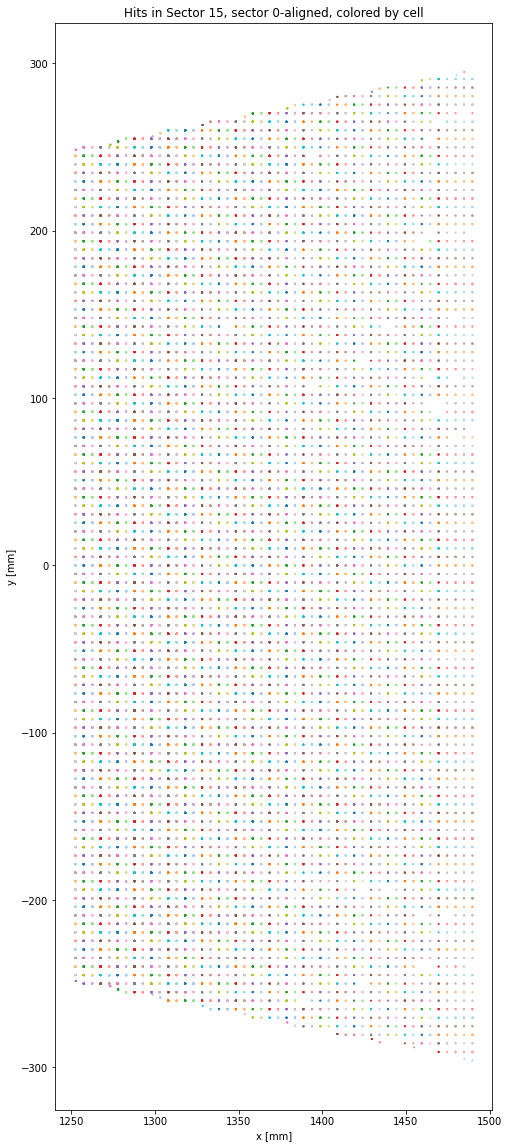

In [177]:
import matplotlib.pyplot as plt
import numpy as np

# --- select hits for a given sector ---
sector_of_interest = 15
mask = sectors == sector_of_interest  # or whichever array you use

# --- create a unique cell ID per (x_cell_idx, y_cell_idx) ---
cell_ids = x_cell_idx[mask] + y_cell_idx[mask] * (x_cell_idx[mask].max() + 1)

# --- assign colors using a colormap ---
n_colors = max(20, len(np.unique(cell_ids)))  # ensure enough colors
colors = plt.cm.tab20(np.mod(cell_ids, 20))   # checkerboard / repeated colors if >20

# --- Plot in raw coordinates ---
plt.figure(figsize=(20, 20))
plt.scatter(
    x[mask], y[mask],
    c=colors,
    s=1,
    alpha=1
)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel("x [mm]")
plt.ylabel("y [mm]")
plt.title(f"Hits in Sector {sector_of_interest}, colored by cell")
plt.show()

# --- Plot in sector 0-aligned coordinates ---
plt.figure(figsize=(20, 20))
plt.scatter(
    x_local[mask], y_local[mask],
    c=colors,
    s=1,
    alpha=1
)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel("x [mm]")
plt.ylabel("y [mm]")
plt.title(f"Hits in Sector {sector_of_interest}, sector 0-aligned, colored by cell")
plt.show()

65
[-390.   -360.   -330.   -300.   -270.   -240.   -238.44 -226.96 -215.48
 -210.   -208.76 -197.27 -180.   -179.07 -167.59 -156.11 -150.   -149.38
 -137.9  -126.42 -120.   -119.7  -108.22  -96.74  -90.    -78.53  -67.05
  -60.    -30.      0.     30.     60.     67.05   78.53   90.     96.74
  108.22  119.7   120.    137.9   149.38  150.    156.11  167.59  179.07
  180.    197.27  210.    226.96  238.44  240.    256.65  268.13  270.
  286.33  297.81  300.    330.    345.71  357.19  360.    386.87  390.
  420.    450.  ]


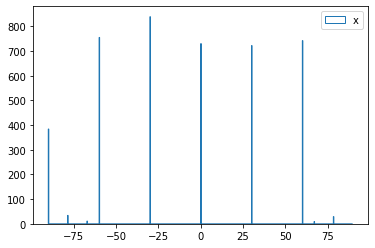

In [121]:
x_bins = np.arange(-90, 90, .30)


x_sel = np.round(x_sel, 2)
unique_x_sel = np.sort(list(set(x_sel)))
print(len(unique_x_sel))
print(unique_x_sel)



#plt.scatter(range(3583), np.sort(list(set(x_sel))))

plt.figure()
plt.hist(x_sel, bins = x_bins, histtype = "step", label = "x")
#plt.hist(y_cell_sel, histtype = "step", label = "y")
plt.legend()
plt.show()

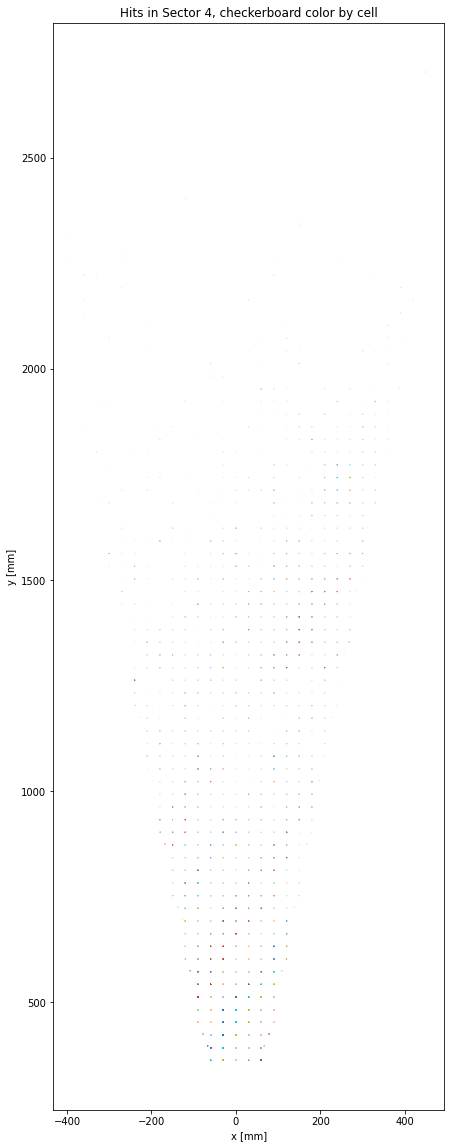

In [122]:


# --- Assign checkerboard-style colors ---
color_idx = (x_cell_sel + y_cell_sel) % n_colors
cell_colors = cmap(color_idx / n_colors)  # normalized to [0,1] for colormap

# --- Plot ---
plt.figure(figsize=(20, 20))
plt.scatter(
    x_sel, y_sel,
    color=cell_colors,
    s=.011,
    alpha=0.8
)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel("x [mm]")
plt.ylabel("y [mm]")
plt.title(f"Hits in Sector {sector_of_interest}, checkerboard color by cell")
plt.show()

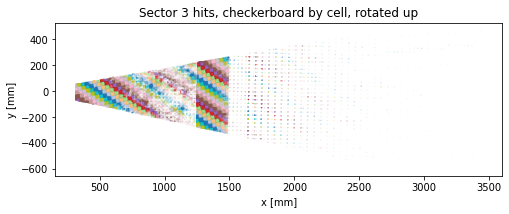

In [ ]:

print(np.min(x), np.max(x))
print(np.min(y), np.max(y))
print(np.min(z), np.max(z))

In [ ]:
X_MAX, Y_MAX, Z_MAX = 3500, 3500, 6000
NUM_X_PATCHES, NUM_Y_PATCHES, NUM_Z_PATCHES = 5, 5, 5
NUM_BINS_X_PATCH, NUM_BINS_Y_PATCH, NUM_BINS_Z_PATCH  = 6, 6, 6

BINS_X = np.linspace(-X_MAX, X_MAX, NUM_X_PATCHES*NUM_BINS_X_PATCH+1) # over all patches
BINS_Y = np.linspace(-Y_MAX, Y_MAX, NUM_Y_PATCHES*NUM_BINS_Y_PATCH+1)
BINS_Z = np.linspace(-Z_MAX, Z_MAX, NUM_Z_PATCHES*NUM_BINS_Z_PATCH+1)



print(BINS_X)

print(x)
print(np.digitize(x, BINS_X))

In [ ]:
latent_space_dim = 128
num_patches = NUM_X_PATCHES * NUM_Y_PATCHES * NUM_Z_PATCHES
import torch

def MLP(feature_vector):
    """
    feature_vector: input of dimension NUM_BINS_X_PATCH*NUM_BINS_Y_PATCH*NUM_BINS_Z_PATCH
    output: MLP embedding of dimension latent_space_dim
    """
    return feature_vector[:latent_space_dim]

def get_positional_embedding():


    # Create a matrix of shape (max_len, embedding_dim)
    positions = torch.arange(num_patches).unsqueeze(1)  # Shape: (max_len, 1)
    dimensions = torch.arange(latent_space_dim).unsqueeze(0)  # Shape: (1, embedding_dim)
    
    # Compute frequency terms
    frequencies = 1 / (10000 ** (2 * (dimensions // 2) / latent_space_dim))
    
    # Compute sinusoidal values
    encoding = torch.zeros((num_patches, latent_space_dim))
    encoding[:, 0::2] = torch.sin(positions * frequencies[:, 0::2])
    encoding[:, 1::2] = torch.cos(positions * frequencies[:, 1::2])
    
    return encoding


for i, event in enumerate(particles):
    if i >= 1:
        break

    print(f"On event {i}...")

    # print(event["event_id"])
    e = np.array(event["total_energy"][:100])
    x = np.array(event["x"])
    y = np.array( event["y"])
    z = np.array(event["z"])

    positional_embedding = get_positional_embedding(i) # num_patches, latent_space_dim


    # make a 3D histogram
    # turn this into a feature vector for the patch and store it in a list of patch features for the event
    # do a 3d histogram and flatten
    hist, edges = np.histogramdd(np.column_stack((x, y, z)), bins=(BINS_X, BINS_Y, BINS_Z), density=True)


    for patch_x_i in range(NUM_X_PATCHES):
        for patch_y_i in range(NUM_Y_PATCHES):
            for patch_z_i in range(NUM_Z_PATCHES):

                patch_index = patch_x_i*NUM_Y_PATCHES*NUM_Z_PATCHES + patch_y_i*NUM_Z_PATCHES + patch_z_i
                patch_hist = hist[patch_x_i*NUM_BINS_X_PATCH:(patch_x_i+1)*NUM_BINS_X_PATCH,
                                  patch_y_i*NUM_BINS_Y_PATCH:(patch_y_i+1)*NUM_BINS_Y_PATCH,
                                  patch_z_i*NUM_BINS_Z_PATCH:(patch_z_i+1)*NUM_BINS_Z_PATCH]
                patch_feature_vector = patch_hist.flatten() # dimension: NUM_BINS_X_PATCH*NUM_BINS_Y_PATCH*NUM_BINS_Z_PATCH
                embedded_patch_feature_vector = MLP(patch_feature_vector) # dimension: latent space of MLP

                embedded_patch_feature_vector_with_positional_embedding = embedded_patch_feature_vector + positional_embedding[patch_index]
                


    
                

   

In [ ]:
tmp = get_positional_embedding(0, 0, 0)
print(tmp)
print(tmp.shape)


plt.figure(figsize=(20, 5))
for i in range(10):
    plt.plot(tmp[i])
plt.show()